# Forecasting the Impact of a New Feature on Reminders Usage

**Product analytics case study · Python · pandas · matplotlib**

## Problem statement
A messaging app offers two related personal-productivity features:

- **My Notes** – a private chat where users save messages, links and notes to themselves.
- **Reminders** – a way to schedule a reminder on a message inside My Notes.

A new feature is being considered: **set a reminder directly from a *received* message** (for example, an appointment confirmation from a business) in one or two taps.

**Question:** based on one month of user activity, how is Reminders used today, and how many *new* Reminders users could this feature realistically bring in?

## Approach
1. Validate the data (uniqueness, duplicates, logical consistency, outliers).
2. Profile engagement: active days, messaging volume and business (transactional) messages.
3. Measure current adoption and depth of use of **My Notes** and **Reminders**.
4. Define the target audience for the new feature and the goal of the estimate (incremental and total adoption).
5. Forecast incremental adoption from a benchmark conversion rate observed in existing behaviour.

## Key results
| Metric | Value |
|---|---|
| Users in dataset | 1,500,000 |
| Active in the last 30 days | 1,161,798 (77.5%) |
| Active users who ever used My Notes | 27.3% |
| My Notes users who ever used Reminders | 25.3% |
| Active users receiving business messages | 35.8% |
| **Forecast: new Reminders users** | **≈ 65.6K (≈ 5.6% of active users)** |


## Data

The dataset holds 30-day activity for 1.5M users. Each row is one user:

- `user_id`: Unique identifier for each user.
- `active_days`: Number of days out of the last 30 days that the user was active.
- `messages_sent`: Total number of messages sent by the user over 30 days.
- `messages_received`: Total number of messages received by the user over 30 days.
- `transactional_received`: Number of transactional business messages received over the last 30 days (not included in messages_received).
- `has_used_my_notes_ever`: Indicator of whether the user has used the My Notes feature (1 = yes, 0 = no).
- `my_notes_days`: Number of days the user used the My Notes feature over the last 30 days.
- `my_notes_messages`: Total messages sent to My Notes over the last 30 days.
- `has_used_reminders_ever`: Indicator of whether the user has used the Reminders feature (1 = yes, 0 = no).
- `reminders_days`: Number of days the user used the Reminders feature over the last 30 days.
- `reminders_messages`: Total reminders set over the last 30 days.

In [1]:
import pandas as pd
import warnings
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
warnings.filterwarnings("ignore")

In [2]:
# The dataset is stored in this repository (gzip-compressed CSV) and loaded directly from GitHub,
# so the notebook runs anywhere without local files.
DATA_URL = (
    "https://github.com/annapmp/projects/raw/main/"
    "feature-adoption-forecast/data/monthly_activity.csv.gz"
)
df = pd.read_csv(DATA_URL)

df.head()

,user_id,active_days,messages_sent,messages_received,transactional_received,has_used_my_notes_ever,my_notes_days,my_notes_messages,has_used_reminders_ever,reminders_days,reminders_messages
0,0,1,249362,0,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,0
2,2,18,1304,1479,90,1,5,67,0,0,0
3,3,21,0,0,2,0,0,0,0,0,0
4,4,0,0,0,0,0,0,0,0,0,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500000 entries, 0 to 1499999
Data columns (total 11 columns):
 #   Column                   Non-Null Count    Dtype
---  ------                   --------------    -----
 0   user_id                  1500000 non-null  int64
 1   active_days              1500000 non-null  int64
 2   messages_sent            1500000 non-null  int64
 3   messages_received        1500000 non-null  int64
 4   transactional_received   1500000 non-null  int64
 5   has_used_my_notes_ever   1500000 non-null  int64
 6   my_notes_days            1500000 non-null  int64
 7   my_notes_messages        1500000 non-null  int64
 8   has_used_reminders_ever  1500000 non-null  int64
 9   reminders_days           1500000 non-null  int64
 10  reminders_messages       1500000 non-null  int64
dtypes: int64(11)
memory usage: 125.9 MB


In [4]:
df.describe()

,user_id,active_days,messages_sent,messages_received,transactional_received,has_used_my_notes_ever,my_notes_days,my_notes_messages,has_used_reminders_ever,reminders_days,reminders_messages
count,1.500000e+06,1.500000e+06,1.500000e+06,1.500000e+06,1.500000e+06,1.500000e+06,1.500000e+06,1.500000e+06,1.500000e+06,1.500000e+06,1.500000e+06
mean,7.499995e+05,1.020252e+01,2.575139e+04,8.888999e+02,1.783722e+01,2.117833e-01,9.533007e-01,1.414584e+01,5.353267e-02,5.548267e-02,5.548267e-02
std,4.330128e+05,1.016552e+01,1.268887e+05,1.416089e+03,3.886939e+01,4.085722e-01,2.416274e+00,3.837477e+01,2.250932e-01,3.483778e-01,3.483778e-01
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,3.749998e+05,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,7.499995e+05,6.000000e+00,1.090000e+02,5.100000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,1.124999e+06,2.000000e+01,1.356000e+03,1.353000e+03,7.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
max,1.499999e+06,3.000000e+01,9.999870e+05,6.387000e+03,2.200000e+02,1.000000e+00,1.800000e+01,3.670000e+02,1.000000e+00,9.000000e+00,9.000000e+00


In [5]:
# Check if 'user_id' contains only unique values
is_unique = df['user_id'].is_unique
print(f"Is 'user_id' unique? {is_unique}")

# If there are duplicate 'user_id' values, count how many are non-unique
if not is_unique:
    # Count of non-unique (duplicate) user IDs
    duplicate_count = df['user_id'].duplicated().sum()
    print(f"Number of non-unique 'user_id' entries: {duplicate_count}")
else:
    print("All 'user_id' values are unique.")

Is 'user_id' unique? True
All 'user_id' values are unique.


The data contains various user metrics, such as days active, messages sent and received, and whether users have utilized certain features (notes and reminders). 
Next let's check data consistency, identifying duplicates, and visualizing some key distributions.

## Data Consistency and Validation

In [6]:
duplicate_count = df.duplicated().sum()
duplicate_count

0

The dataset is complete with no missing values, and no duplicates were found.
I'll plot the distribution of `active_days` to identify user engagement levels and segment users. 
Then, explore `messages_sent` using a box plot to understand message usage patterns.

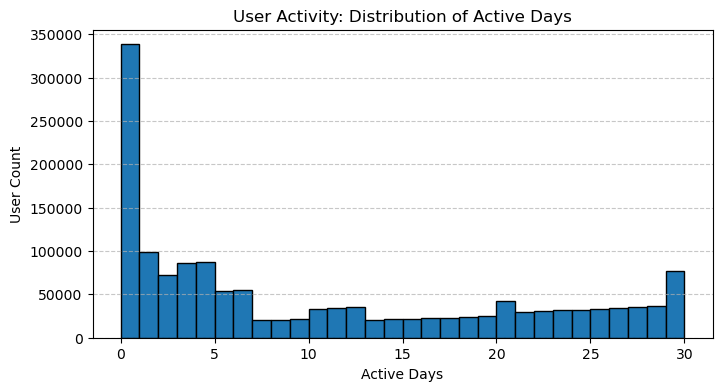

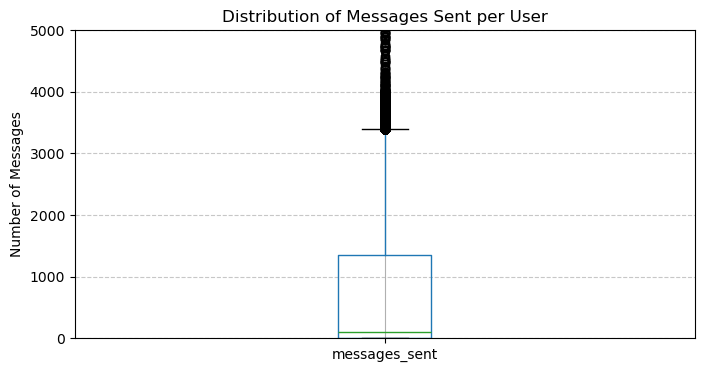

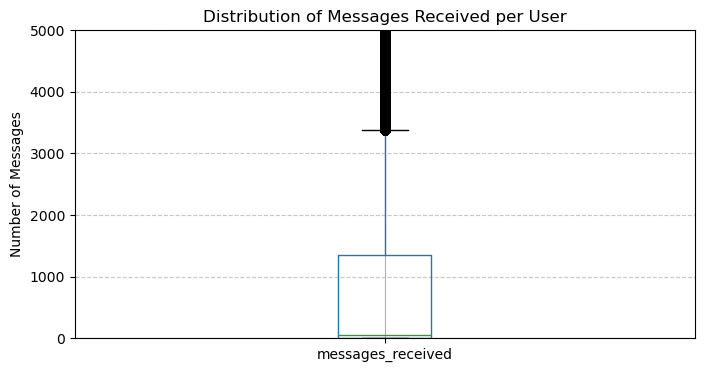

In [7]:
# Plotting the distribution of active days to understand user engagement levels
plt.figure(figsize=(8, 4))
df['active_days'].plot(kind='hist', bins=30, edgecolor='black')
plt.title('User Activity: Distribution of Active Days')
plt.xlabel('Active Days')
plt.ylabel('User Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Box plot for messages sent per user to visualize the spread and identify outliers
plt.figure(figsize=(8, 4))
df.boxplot(column='messages_sent')
plt.title('Distribution of Messages Sent per User')
plt.ylabel('Number of Messages')
plt.ylim(0, 5000)  
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Box plot for messages received per user to visualize the spread and identify outliers
plt.figure(figsize=(8, 4))
df.boxplot(column='messages_received')
plt.title('Distribution of Messages Received per User')
plt.ylabel('Number of Messages')
plt.ylim(0, 5000)  
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

**The distribution of active days shows several distinct groups:**

- `Inactive users (0 days)`: Possibly churned users or users who didn’t engage during the month.
- `Occasional users (up to 7 days)`: Likely to be sporadic users, perhaps checking messages infrequently.
- `Moderate users (around 20 days)`: Likely work-focused users engaging mostly on weekdays.
- `High-engagement users (around 30 days)`: Active daily users, perhaps using the app as their primary messenger.

**The messages sent/received distribution** reveals many low-activity users, but a significant number of high outliers are present. Limiting the y-axis helped highlight the main cluster of users, with most active users sending fewer than 5,000 messages monthly.

I'll investigate the extreme outliers in messages_sent to determine whether these are valid high-usage patterns or potential data anomalies.

In [8]:
# Checking for extreme values in messages sent
max_messages_sent = df['messages_sent'].max()
max_messages_received = df['messages_received'].max()

print('max messages sent:', max_messages_sent) 
print('max messages received:', max_messages_received)

max messages sent: 999987
max messages received: 6387


- The `maximum number` of messages sent by a user in a month is nearly one million, which is unusually high and likely an anomaly. 
- The highest messages received count `6,387` appears more plausible, potentially representing high-traffic users or those engaged in group messaging.
- I will exclude such extreme values in further visualizations to avoid skewing insights.

## Business Message Engagement

Next, let’s examine engagement with business messages `transactional_received` and determine the proportion of users engaging with this feature.

For the purposes of this analysis, we will exclude churned users to focus on active engagement patterns

In [26]:
total_users = df.shape[0]
total_users

1500000

In [9]:
df_active_users = df[df['active_days'] > 0]

In [27]:
df_active_users.shape[0]

1161798

In [28]:
df_churned_users = df[df['active_days'] == 0]
df_churned_users.shape[0]

338202

In [12]:
# Retention Rate
retention_rate = df_active_users.shape[0]/df.shape[0] *100
retention_rate

77.4532

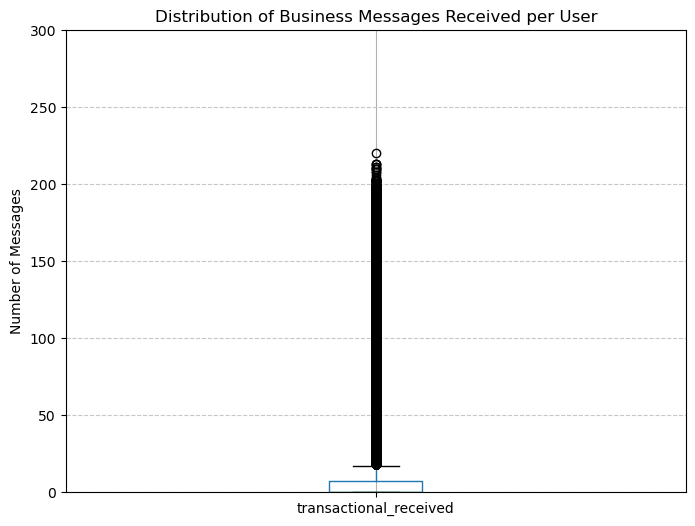

Business message count: 416184
Business message percentage: 35.822406304710455
Mean business messages per user: 64.28845895084866


In [13]:
# Visualize the distribution of transactional (business) messages received per user
plt.figure(figsize=(8, 6))
df.boxplot(column='transactional_received')
plt.title('Distribution of Business Messages Received per User')
plt.ylabel('Number of Messages')
plt.ylim(0, 300)  
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Calculating the number and proportion of users who received business messages
business_message_users = df_active_users[df_active_users['transactional_received'] > 0]
business_message_count = business_message_users['user_id'].count()
total_active_users = df_active_users['user_id'].count()
business_message_percentage = business_message_count / total_active_users * 100

# Mean number of business messages per user who has received any business messages
mean_business_messages_per_user_alt = business_message_users['transactional_received'].mean()


print('Business message count:', business_message_count) 
print('Business message percentage:', business_message_percentage) 
print( 'Mean business messages per user:', mean_business_messages_per_user_alt)

- Around `35.8%` of active users have received `business messages`, indicating a substantial segment potentially engaging with business accounts.
- Most users receive fewer than `250` business messages, suggesting a moderate level of interaction for the majority.
- Mean number of business messages per active user who receives them is approximately `64.3` messages. This indicates that active business message users likely subscribe to multiple business accounts or interact frequently with business contacts.

Next I'll analyze the `current usage of reminders` by checking the usage metrics for users who have used the reminders feature.
And count users who have used reminders, the average reminders_days, and reminders_messages.

In [14]:
## validation of reminder usage field
not_using_reminders_days_total = df.loc[df['has_used_reminders_ever'] == 0, 'reminders_days'].sum()
not_using_reminders_days_total

0

In [15]:
reminders_usage = df_active_users[df_active_users['has_used_reminders_ever'] == 1]

# Key metrics for current reminders usage
current_reminders_stats = {
    "Total_users_used_reminders": reminders_usage['user_id'].nunique(),
    "Avg_reminders_days": reminders_usage['reminders_days'].mean().round(2),
    "Avg_reminders_messages": reminders_usage['reminders_messages'].mean().round(2),
    "Median_reminders_days": reminders_usage['reminders_days'].median(),
    "Median_reminders_messages": reminders_usage['reminders_messages'].median(),
    "Max_reminders_messages": reminders_usage['reminders_messages'].max()
}

current_reminders_stats

{'Total_users_used_reminders': 80299,
 'Avg_reminders_days': 1.04,
 'Avg_reminders_messages': 1.04,
 'Median_reminders_days': 1.0,
 'Median_reminders_messages': 1.0,
 'Max_reminders_messages': 9}

These figures indicate that reminders usage is relatively low among users who have accessed the feature

Let's do the same analysis for `My Notes` usage among users to understand its current adoption and potential impact on reminders.

In [16]:
my_notes_usage = df_active_users[df_active_users['has_used_my_notes_ever'] == 1]

# Key metrics for current My Notes usage
my_notes_stats = {
    "Total_users_used_my_notes": my_notes_usage['user_id'].nunique(),
    "Avg_my_notes_days": my_notes_usage['my_notes_days'].mean().round(2),
    "Avg_my_notes_messages": my_notes_usage['my_notes_messages'].mean().round(2),
    "Median_my_notes_days": my_notes_usage['my_notes_days'].median(),
    "Median_my_notes_messages": my_notes_usage['my_notes_messages'].median(),
    "Max_my_notes_messages": my_notes_usage['my_notes_messages'].max(),
}

my_notes_stats

{'Total_users_used_my_notes': 317675,
 'Avg_my_notes_days': 4.5,
 'Avg_my_notes_messages': 66.79,
 'Median_my_notes_days': 4.0,
 'Median_my_notes_messages': 57.0,
 'Max_my_notes_messages': 367}

This shows that `My Notes` has higher engagement compared to the `Reminders feature`.

In [17]:
# Percent of User using My Notes out of all users
my_notes_usage_percent = my_notes_usage['user_id'].count() / df_active_users['user_id'].count() *100
my_notes_usage_percent

27.343393601985888

`27%` out of all active users use My Notes 

In [18]:
# Percentage of Users who ever used reminders amonth those who ever used My Notes
reminders_notes_perc = reminders_usage['user_id'].count() / my_notes_usage['user_id'].count()
reminders_notes_perc

0.2527709136696309

`25%` - proportion of notes users who have utilized reminders at least once.

## Target Audience for New Feature
To assess the impact of the new reminder feature, I will identify users who are likely to benefit from it and show high potential for adoption.

**Users Receiving Business Messages**: This group represents the primary target audience for the feature. These users are more likely to receive appointment reminders or other scheduled communications from businesses, making them ideal candidates for a feature that allows easy conversion of these messages into reminders.

**Active Users Who Receive Messages**: Although this group may also benefit from the feature, estimating adoption is more challenging for general message recipients. Unlike business messages, which are more likely to contain structured date and time information, regular messages may lack a consistent format or may not relate to events that require reminders. Personal messages may contain only a date, only a time, or none at all, making them less predictable as a source for reminders.

Next important factor in estimating the impact of a new reminder feature is to define the **goal of the estimation**:

1. To measure `incremental adoption`. Here we need to exclude users who are already using reminders. As these users have already demonstrated an interest in using reminders and may adopt the new feature without any additional impact on overall engagement or adoption. By focusing on users who have not previously used reminders, we can gauge the extent to which the new feature expands the user base for reminders. This approach is common in evaluating incremental impact, as it highlights `growth in usage attributable directly to the new feature`.

2. To measure `total adoption and engagement` with reminders, then it makes sense to include existing reminder users. Some existing reminder users may find the new feature valuable and might increase their use of reminders if the feature adds convenience. Including them would give a broader picture of how the feature might impact `overall engagement` with reminders, even if they’re not new users.

In [19]:
active_users_count = df_active_users['user_id'].count() 

# Scenario 1: Business message receivers who haven't used reminders
target_audience_1 = business_message_users[business_message_users['has_used_reminders_ever'] == 0]
target_audience_count_1 = target_audience_1['user_id'].count()
target_audience_percentage_1 = target_audience_count_1 / active_users_count * 100

# Scenario 2: Active users who received messages and haven't used reminders
target_audience_2 = df_active_users[
    (df_active_users['messages_received'] != 0) &
    (df_active_users['has_used_reminders_ever'] == 0)
]
target_audience_count_2 = target_audience_2['user_id'].count() 
target_audience_percentage_2 = target_audience_count_2 / active_users_count * 100

# Scenario 3: Business message receivers
target_audience_3 = business_message_users
target_audience_count_3 = target_audience_3['user_id'].count()
target_audience_percentage_3 = target_audience_count_3 / active_users_count * 100

# Scenario 4: Active users who received messages
target_audience_4 = df_active_users[(df_active_users['messages_received'] != 0)]
target_audience_count_4 = target_audience_4['user_id'].count() 
target_audience_percentage_4 = target_audience_count_4 / active_users_count * 100

# Results

print(f"Business Messages Receivers (who haven't used reminders) Count: {target_audience_count_1}")
print(f"Business Messages Receivers (who haven't used reminders) Percentage of All Active Users: {target_audience_percentage_1:.2f}%")
print('--------------------')
print(f"Active Users Receivers (who haven't used reminders) Count: {target_audience_count_2}")
print(f"Active Users Receivers (who haven't used reminders) Percentage of All Active Users: {target_audience_percentage_2:.2f}%")
print('--------------------')
print(f"Business Messages Receivers Count: {target_audience_count_3}")
print(f"Business Messages Receivers Percentage of All Active Users: {target_audience_percentage_3:.2f}%")
print('--------------------')
print(f"Active Users Receivers Count: {target_audience_count_4}")
print(f"Active Users Receivers Percentage of All Active Users: {target_audience_percentage_4:.2f}%")

Business Messages Receivers (who haven't used reminders) Count: 377387
Business Messages Receivers (who haven't used reminders) Percentage of All Active Users: 32.48%
--------------------
Active Users Receivers (who haven't used reminders) Count: 881810
Active Users Receivers (who haven't used reminders) Percentage of All Active Users: 75.90%
--------------------
Business Messages Receivers Count: 416184
Business Messages Receivers Percentage of All Active Users: 35.82%
--------------------
Active Users Receivers Count: 961980
Active Users Receivers Percentage of All Active Users: 82.80%


**Based on the assumptions and statistics outlined above**, I will use the following target groups to ensure forecast accuracy for the new feature estimation:

 - **Users who have not previously used reminders**: This group represents the primary source of incremental adoption for the new feature, as they have not yet engaged with reminders and may find this feature particularly beneficial.

- **Business message recipients**: This segment has high potential for adoption due to the clear benefits of the feature, as business messages often contain structured information (e.g., appointment details) that can be easily converted into reminders. 

In [20]:
# Data validity check: check if exist users who have used reminders (has_used_reminders_ever == 1)
# and who have never used notes (has_used_my_notes_ever == 0)
reminder_no_notes_users = df[(df['has_used_reminders_ever'] == 1) & (df['has_used_my_notes_ever'] == 0)]

# Display the result or count the number of such users
print(reminder_no_notes_users)
print(f"Number of users who have used reminders but never used notes: {reminder_no_notes_users['user_id'].count()}")

Empty DataFrame
Columns: [user_id, active_days, messages_sent, messages_received, transactional_received, has_used_my_notes_ever, my_notes_days, my_notes_messages, has_used_reminders_ever, reminders_days, reminders_messages]
Index: []
Number of users who have used reminders but never used notes: 0


In [21]:
# Count of My Notes users (target audience for the reminders feature)
my_notes_users_count = df[df['has_used_my_notes_ever'] == 1]['user_id'].count()

# Count of users who have used reminders within My Notes
reminder_users_count = df[df['has_used_reminders_ever'] == 1]['user_id'].count()

# Adoption rate of reminders within My Notes
adoption_rate = reminder_users_count / my_notes_users_count * 100
print(f"Adoption rate of reminders among My Notes users: {adoption_rate:.2f}%")

Adoption rate of reminders among My Notes users: 25.28%


This rate best for estimating the overall appeal of the reminders feature, regardless of usage frequency.
Cons: It includes infrequent or one-time users, which might slightly inflate the adoption rate without reflecting sustained engagement.

In [22]:
# Adoption rate of reminders among active My Notes users
active_reminder_users_count = df_active_users[df_active_users['reminders_days'] != 0]['user_id'].count()
active_notes_users_count = df_active_users[df_active_users['my_notes_days'] != 0]['user_id'].count()
reminder_share_active_notes_users = active_reminder_users_count / active_notes_users_count
print(f"Adjusted adoption rate (active reminders users among active notes users): {reminder_share_active_notes_users*100:.2f}%")

Adjusted adoption rate (active reminders users among active notes users): 17.37%


Measuring adoption among actively engaged My Notes users, giving a more accurate view of sustained or frequent use of reminders.
Pros: Excludes occasional or one-time users, offering a clearer picture of how reminders resonate with users actively engaged with My Notes.

In [23]:
# Defining target audience
primary_adopters = business_message_users[business_message_users['has_used_reminders_ever'] == 0]

In [24]:
# Estimating Impact: Predicted number of new reminder users from primary adopters audience
primary_adopters_count = primary_adopters['user_id'].count()  
predicted_new_reminder_users = primary_adopters_count * reminder_share_active_notes_users
print(f"Predicted number of new reminder users from primary adopters audience: {predicted_new_reminder_users:.0f}")

# Percentage Impact on Active Users
impact_percentage = predicted_new_reminder_users / active_users_count 
print(f"Percentage of active users impacted: {impact_percentage*100:.2f}%")

print("\nSummary:")
print(f"Estimated impact: {impact_percentage *100:.2f}% of active users could adopt the new feature.")

Predicted number of new reminder users from primary adopters audience: 65563
Percentage of active users impacted: 5.64%

Summary:
Estimated impact: 5.64% of active users could adopt the new feature.


## Conclusion
Impact Estimation: Projected that about `~6%` of active users may adopt the new reminder feature.

## Proposed next steps to increase the accuracy of the forecast
- Tracking message patterns containing date/time stamps could improve forecast accuracy. For example by knowing how ofter business messages/regular messages include timestamp could help to predict number of such messages per user.
- Analyze historical behavior for similar features. By examining how users engaged with previous features that have similar characteristics, we can identify patterns, expected adoption rates, and potential challenges. For example, if the app has a feature that prompts users to take action based on incoming messages (like flagging important messages or marking them for follow-up), that would be a useful comparison. By comparing the new feature with similar past features, we can set realistic benchmarks.
- If possible, segment users who frequently receive business messages as they may show stronger adoption. Users engaging in professional communication might find appointment reminders particularly valuable.
- Observing how long users continued to use the previous feature can help forecast retention for the new feature, indicating whether it’s likely to be a one-time or recurring use case.